# 03 GenAI Implementation (Senior)

## Objective
Demonstrate end-to-end reproducibility, telemetry, and robustness checks.

## Run order
1. Setup imports and repo path.
2. Load config (YAML).
3. Download nongated Hugging Face models (generation + embeddings).
4. Run retrieval + generation with telemetry logs.
5. Run golden prompt evaluation and capture results.
6. Perform a deterministic check and document nondeterminism risks.

## Notes on determinism
- GPU kernels can be nondeterministic even with fixed seeds.
- This notebook is CPU-first by default, but still logs seed/device/dtype for traceability.

In [1]:
# stdlib pathlib (filesystem paths)
from pathlib import Path

# stdlib sys (Python path management)
import sys

# stdlib json (write outputs)
import json

# numpy (numeric arrays)
import numpy as np

# matplotlib (visualization)
import matplotlib.pyplot as plt

# scikit-learn cosine similarity (vector similarity)
from sklearn.metrics.pairwise import cosine_similarity

# Bootstrap repo root on sys.path so `import src...` works from notebooks.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "src").exists():
    repo_root = repo_root.parent
if (repo_root / "src").exists() and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# src/utils/pathing.py
from src.utils.pathing import ensure_repo_root_on_sys_path  # src/utils/pathing.py

# src/llm/config.py
from src.llm.config import load_llm_config  # src/llm/config.py
# src/llm/model_loading.py
from src.llm.model_loading import (  # src/llm/model_loading.py
    load_embedding_model,
    load_generation_model,
)
# src/llm/tokenization.py
from src.llm.tokenization import load_tokenizer  # src/llm/tokenization.py
# src/llm/generation.py
from src.llm.generation import generate_text  # src/llm/generation.py
# src/llm/eval.py
from src.llm.eval import GoldenPromptCase, evaluate_golden_prompts  # src/llm/eval.py
# src/llm/telemetry.py
from src.llm.telemetry import (  # src/llm/telemetry.py
    TimingContext,
    build_token_usage_record,
    log_token_usage,
    utc_timestamp,
)

repo_root = ensure_repo_root_on_sys_path(Path.cwd())

In [2]:
config_path = repo_root / "config" / "llm_interview.yaml"
config = load_llm_config(config_path)

run_timestamp = utc_timestamp()
logs_dir = Path(config.logging.logs_dir)
results_dir = Path(config.logging.results_dir)

token_log_path = logs_dir / f"llm_tokens_{run_timestamp}.jsonl"
timing_log_path = logs_dir / f"llm_timing_{run_timestamp}.jsonl"
results_path = results_dir / f"genai_eval_{run_timestamp}.json"

logs_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

config

LLMConfig(run_id='genai_interview', seed=42, model=ModelConfig(model_id='sshleifer/tiny-gpt2', tokenizer_id='sshleifer/tiny-gpt2', revision=None), embeddings=EmbeddingConfig(model_id='sentence-transformers/paraphrase-MiniLM-L3-v2'), device=DeviceConfig(device_strategy='cpu', device_map='cpu', torch_dtype='float32', quantization='none'), tokenization=TokenizationConfig(padding='max_length', truncation=True, max_length=128), generation=GenerationConfig(max_new_tokens=64, temperature=0.7, top_p=0.9, top_k=50, repetition_penalty=1.1, do_sample=True), logging=LoggingConfig(output_root='outputs', logs_dir='outputs/logs', results_dir='outputs/results'))

In [3]:
with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.model.model_id,
    step_name="model_and_tokenizer_load",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
):
    tokenizer = load_tokenizer(config)
    model = load_generation_model(config)

with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.embeddings.model_id,
    step_name="embedding_model_load",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
):
    embedding_model = load_embedding_model(config)

model

`torch_dtype` is deprecated! Use `dtype` instead!


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 2)
    (wpe): Embedding(1024, 2)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((2,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=6, nx=2)
          (c_proj): Conv1D(nf=2, nx=2)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((2,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=8, nx=2)
          (c_proj): Conv1D(nf=2, nx=8)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((2,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=2, out_features=50257, bias=False)
)

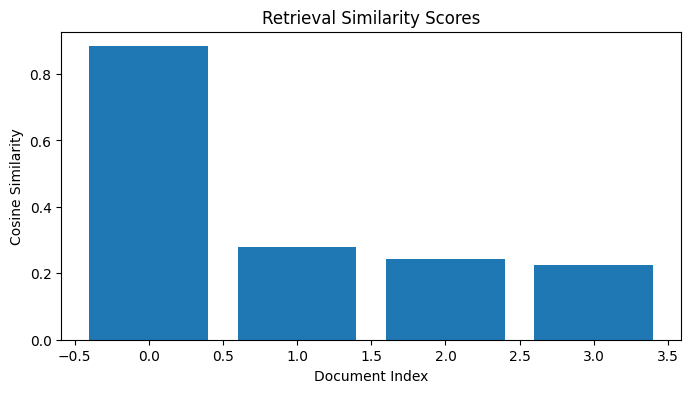

'Telemetry logs help trace latency and token usage.'

In [4]:
corpus = [
    "Telemetry logs help trace latency and token usage.",
    "RAG grounds responses in retrieved documents.",
    "Deterministic settings reduce output variance.",
    "Golden prompts catch regressions and drift.",
]

query = "How do telemetry logs help with traceability?"

with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.embeddings.model_id,
    step_name="embedding_encode",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
    batch_size=len(corpus),
    sequence_length=None,
):
    corpus_embeddings = embedding_model.encode(corpus, convert_to_numpy=True)
    query_embedding = embedding_model.encode([query], convert_to_numpy=True)

similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
ranked_indices = np.argsort(similarities)[::-1]

retrieved_text = corpus[ranked_indices[0]]

plt.figure(figsize=(8, 4))
plt.bar(range(len(similarities)), similarities)
plt.title("Retrieval Similarity Scores")
plt.xlabel("Document Index")
plt.ylabel("Cosine Similarity")
plt.show()

retrieved_text

In [5]:
prompt = (
    "Use the context to answer the question.\n"
    f"Context: {retrieved_text}\n"
    f"Question: {query}\n"
    "Answer:"
)

with TimingContext(
    log_path=timing_log_path,
    run_id=config.run_id,
    model_id=config.model.model_id,
    step_name="generation",
    device=config.device.device_strategy,
    torch_dtype=config.device.torch_dtype,
    batch_size=1,
    sequence_length=config.tokenization.max_length,
):
    result = generate_text(model, tokenizer, prompt, config)

record = build_token_usage_record(
    generation_result=result,
    run_id=config.run_id,
    model_id=config.model.model_id,
    task_name="rag_answer",
    input_ref=str(config_path),
    output_ref=str(results_path),
)
log_token_usage(token_log_path, record)

result.output_text

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'Use the context to answer the question.\nContext: Telemetry logs help trace latency and token usage.\nQuestion: How do telemetry logs help with traceability?\nAnswer:oho Jratisf intermittent intermittent Rh Participation reviewingoho intermittent pawnmediately scalp reviewingimura dispatch circumcised directly confirSherScene reviewing conservation substhibit Process Rh stairs004 Rhting credibility intermittentahn conservation credibility antibiotichibit Money Amph intermittent heirreementoho trilogy ESV sexuality ESVJD stairs Habit stairs administration ESVGaza things stairsiken stairs Rhohohibit Jr reborn'

In [6]:
golden_fixture_path = (
    repo_root
    / "Interview"
    / "Generative"
    / "golden_prompts_fixture.json"
)
fixture_payload = json.loads(golden_fixture_path.read_text(encoding="utf-8"))

golden_cases = [
    GoldenPromptCase(
        prompt=item["prompt"],
        expected_substrings=item["expected_substrings"],
        forbidden_substrings=item["forbidden_substrings"],
    )
    for item in fixture_payload[:2]
]

additional_output = generate_text(
    model,
    tokenizer,
    golden_cases[1].prompt,
    config,
)

eval_summary = evaluate_golden_prompts(
    golden_cases,
    [result.output_text, additional_output.output_text],
)

results_payload = {
    "retrieved_text": retrieved_text,
    "generation": result.output_text,
    "evaluation": eval_summary,
    "seed": config.seed,
    "device": config.device.device_strategy,
    "torch_dtype": config.device.torch_dtype,
}
results_path.write_text(json.dumps(results_payload, indent=2), encoding="utf-8")

eval_summary

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


{'pass_rate': 0.0,
 'total_cases': 2,
 'results': [{'prompt': 'Why is reproducibility important in ML?',
   'expected_hits': [],
   'forbidden_hits': [],
   'passed': False},
  {'prompt': 'What should telemetry logs capture?',
   'expected_hits': [],
   'forbidden_hits': [],
   'passed': False}]}

In [7]:
repeat_a = generate_text(model, tokenizer, prompt, config)
repeat_b = generate_text(model, tokenizer, prompt, config)

{
    "repeat_a_matches_repeat_b": repeat_a.output_text == repeat_b.output_text,
    "note": "GPU runs may still show minor nondeterminism even with fixed seeds.",
}

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


{'repeat_a_matches_repeat_b': True,
 'note': 'GPU runs may still show minor nondeterminism even with fixed seeds.'}